In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [11]:
df = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/preprocessed_not_standardized.csv')

In [12]:
print(df.columns)

Index(['period', 'appreciation_return', 'availability_rate',
       'available_df_direct', 'avg_sale_price', 'cap_rate', 'market_cap_rate',
       'starts_sf', 'starts_sf_12_mo', 'demand_sf', 'demolished_sf',
       'gross_delivered_sf', 'inventory_sf', 'leasing_sf_total',
       'asking_rent_growth', 'asking_rent_growth_12_mo', 'net_absorp_sf',
       'net_absorp_sf_12_mo', 'net_delivered_sf', 'net_delivered_sf_12_mo',
       'occupancy_rate', 'sales_volume', 'sold_building_sf', 'vacancy_rate',
       'under_construction_sf', 'total_sales_transactions',
       'bond_yield_10yr_x', 'one_yr_inf_exp', 'two_yr_inf_exp',
       'three_yr_inf_exp', 'four_yr_inf_exp', 'five_yr_inf_exp',
       'six_yr_inf_exp', 'seven_yr_inf_exp', 'eight_yr_inf_exp',
       'nine_yr_inf_exp', 'ten_yr_inf_exp', 'ten_yr_risk_premium',
       'fed_funds_rate', 'cmbs_to_gdp', 'bond_yield_10yr_y', 'availability'],
      dtype='object')


In [9]:
df.head()

,appreciation_return,available_df_direct,demand_sf,net_delivered_sf,bond_yield_10yr_x,three_yr_inf_exp,fed_funds_rate,cmbs_to_gdp
period,,,,,,,,
2000-01-01,1.996212,NaN,233634640.0,3723806.0,6.480000,3.311378,5.676667,10.858744
2000-04-01,0.029603,NaN,238588112.0,2151416.0,6.176667,3.338417,6.273333,10.895663
2000-07-01,-0.951823,NaN,236425552.0,2132880.0,5.893333,3.117543,6.520000,11.034501
2000-10-01,-2.447272,NaN,238998704.0,3184278.0,5.566667,3.025306,6.473333,11.178302
2001-01-01,-3.037886,NaN,239546624.0,2678319.0,5.050000,2.545579,5.593333,10.963645


In [4]:
df.shape

(100, 42)

In [13]:
#keep only the following variables appreciation_return available_df_direct demand_sf net_delivered_sf bond_yield_10yr_x three_yr_inf_exp fed_funds_rate cmbs_to_gdp

df = df[['period','appreciation_return', 'available_df_direct', 'demand_sf', 'net_delivered_sf', 'bond_yield_10yr_x', 'three_yr_inf_exp', 'fed_funds_rate', 'cmbs_to_gdp', 'market_cap_rate']]
df.head()

,period,appreciation_return,available_df_direct,demand_sf,net_delivered_sf,bond_yield_10yr_x,three_yr_inf_exp,fed_funds_rate,cmbs_to_gdp,market_cap_rate
0,2000-01-01,1.996212,NaN,233634640.0,3723806.0,6.480000,3.311378,5.676667,10.858744,9.707598
1,2000-04-01,0.029603,NaN,238588112.0,2151416.0,6.176667,3.338417,6.273333,10.895663,9.737211
2,2000-07-01,-0.951823,NaN,236425552.0,2132880.0,5.893333,3.117543,6.520000,11.034501,9.913068
3,2000-10-01,-2.447272,NaN,238998704.0,3184278.0,5.566667,3.025306,6.473333,11.178302,9.950081
4,2001-01-01,-3.037886,NaN,239546624.0,2678319.0,5.050000,2.545579,5.593333,10.963645,10.011605


In [15]:
#conver period into datetime and index
df['period'] = pd.to_datetime(df['period'])
df = df.set_index('period')

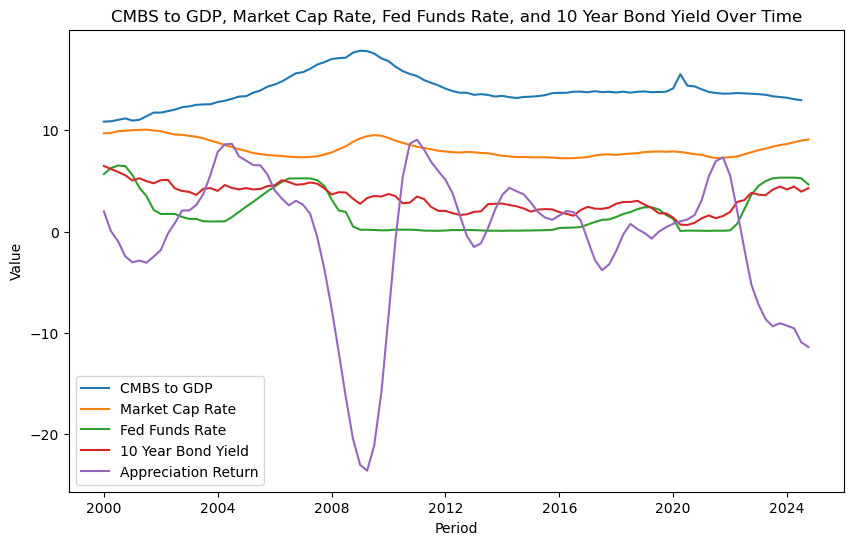

In [19]:
#plot cmbs_to_gdp and market_cap_rate using the period as time index, include also fed_funds_rate
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['cmbs_to_gdp'], label='CMBS to GDP')
plt.plot(df.index, df['market_cap_rate'], label='Market Cap Rate')
plt.plot(df.index, df['fed_funds_rate'], label='Fed Funds Rate')
plt.plot(df.index, df['bond_yield_10yr_x'], label='10 Year Bond Yield')
plt.plot(df.index, df['appreciation_return'], label='Appreciation Return')
plt.xlabel('Period')
plt.ylabel('Value')
plt.title('CMBS to GDP, Market Cap Rate, Fed Funds Rate, and 10 Year Bond Yield Over Time')
plt.legend()
plt.show()


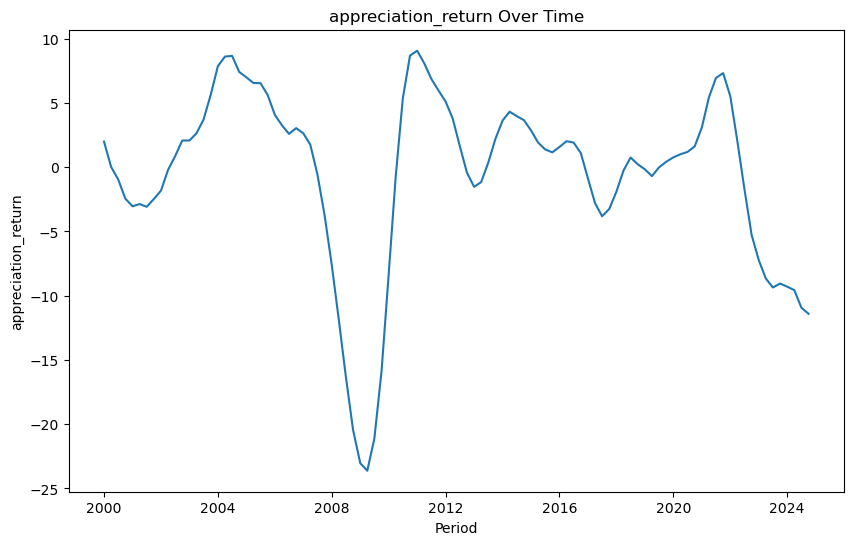

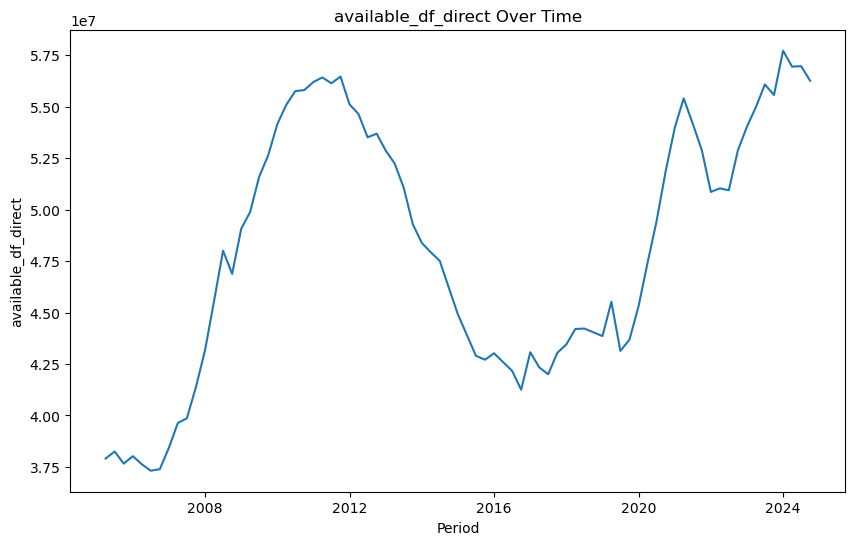

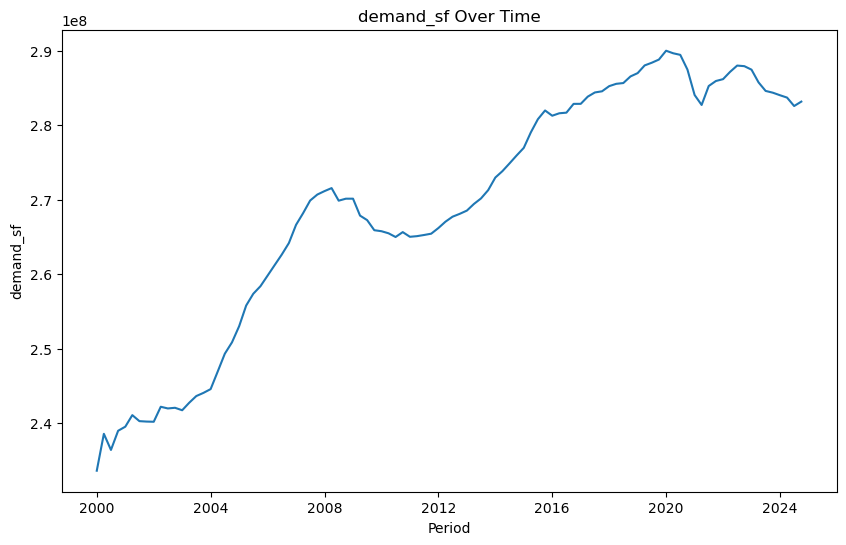

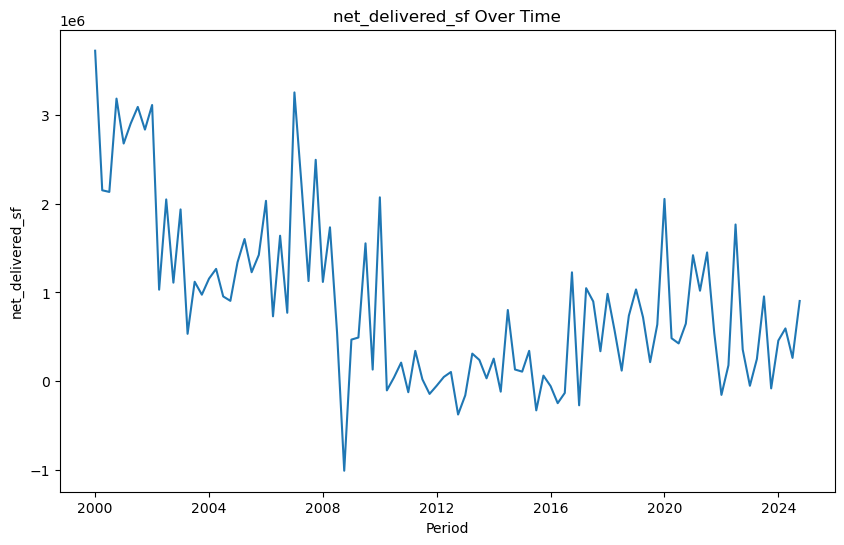

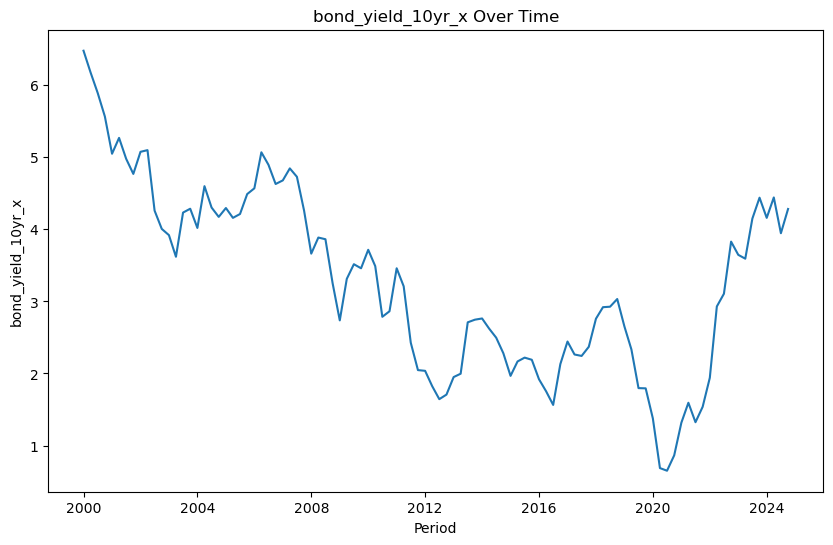

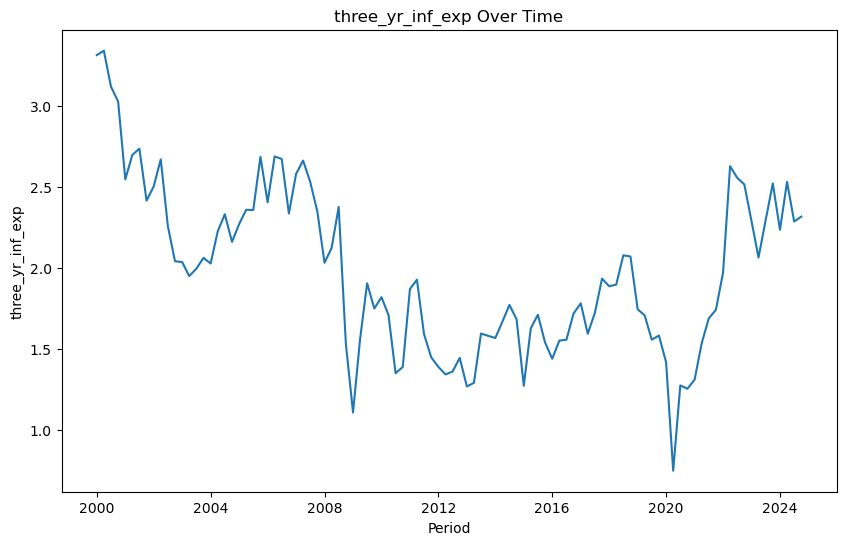

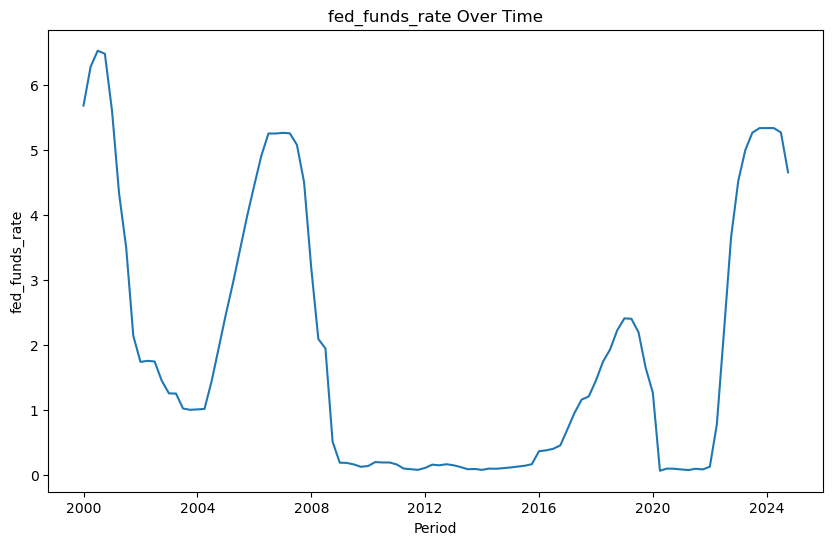

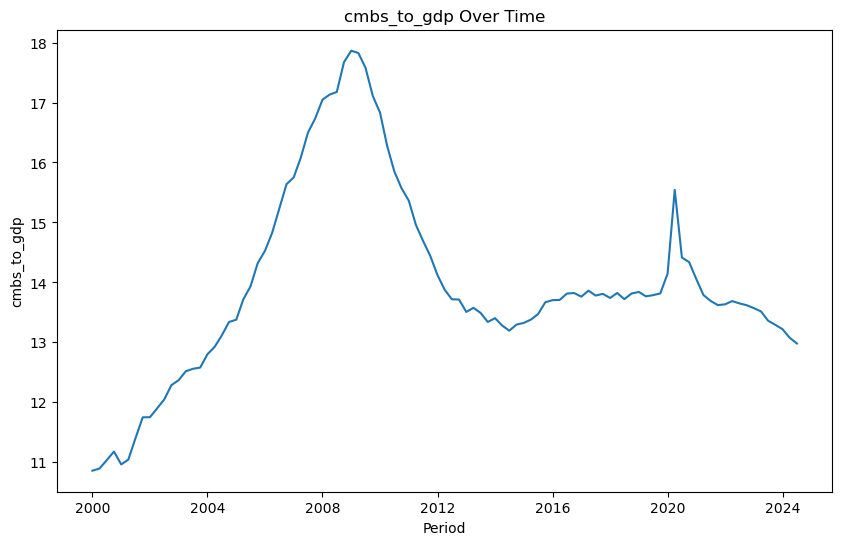

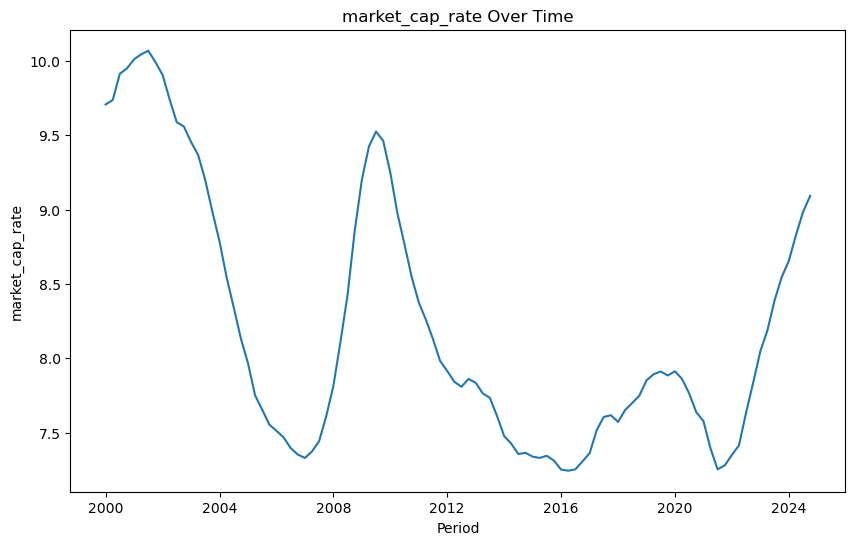

In [20]:
#generate a number of line plots to visualize the data, but each variabel on a seperate line plot with period as the time
for col in df.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df[col])
    plt.xlabel('Period')
    plt.ylabel(col)
    plt.title(f'{col} Over Time')
    plt.show()
    

In [21]:
df.shape

(100, 9)


--- BASIC INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2000-01-01 to 2024-10-01
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appreciation_return  100 non-null    float64
 1   demand_sf            100 non-null    float64
 2   net_delivered_sf     100 non-null    float64
 3   bond_yield_10yr_x    100 non-null    float64
 4   three_yr_inf_exp     100 non-null    float64
 5   fed_funds_rate       100 non-null    float64
 6   cmbs_to_gdp          100 non-null    float64
 7   market_cap_rate      100 non-null    float64
dtypes: float64(8)
memory usage: 7.0 KB
None

--- MISSING VALUES ---
appreciation_return    0
demand_sf              0
net_delivered_sf       0
bond_yield_10yr_x      0
three_yr_inf_exp       0
fed_funds_rate         0
cmbs_to_gdp            0
market_cap_rate        0
dtype: int64

--- STATISTICAL SUMMARY ---
       appreciation_return     demand_s

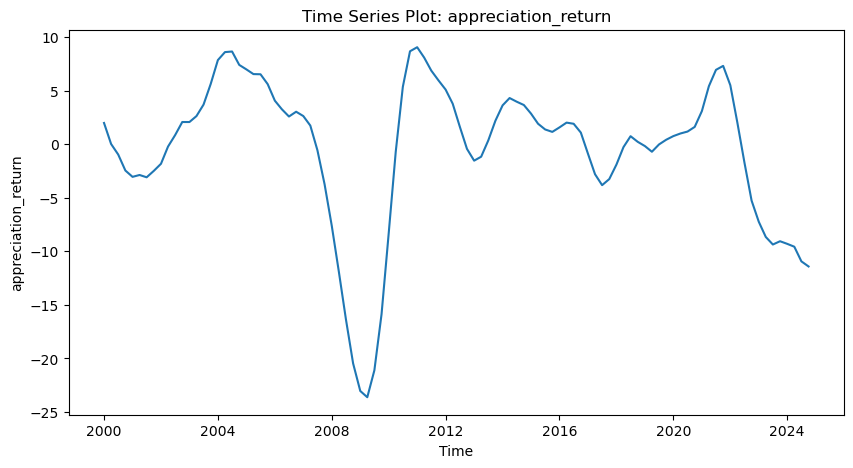

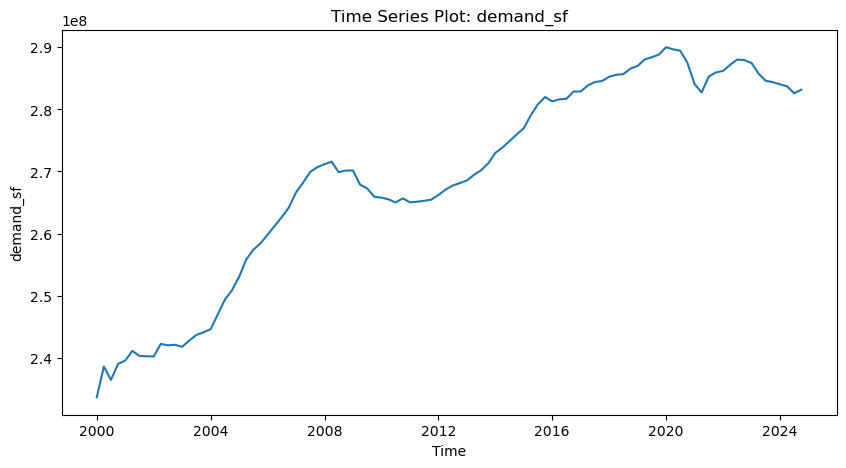

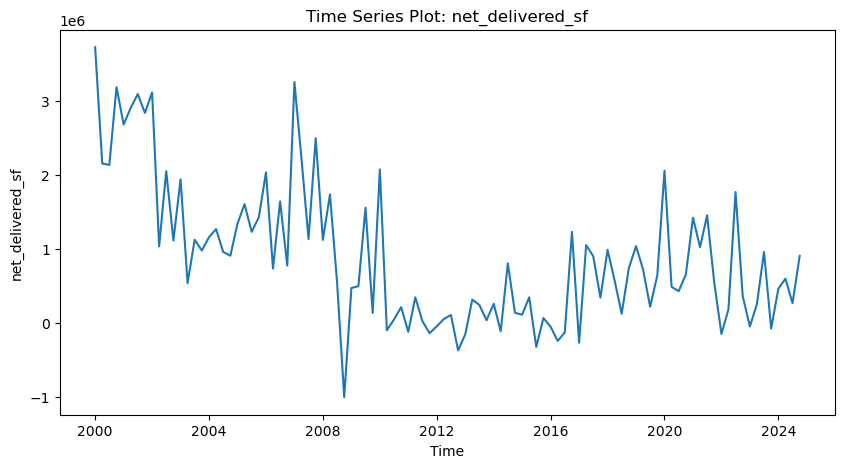

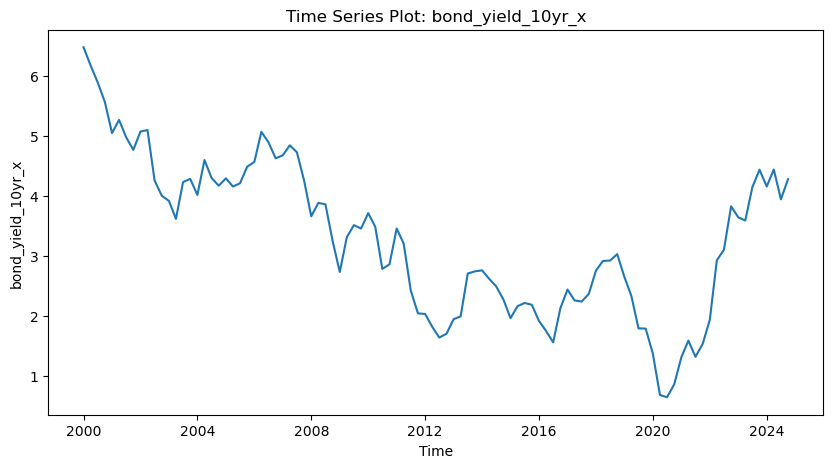

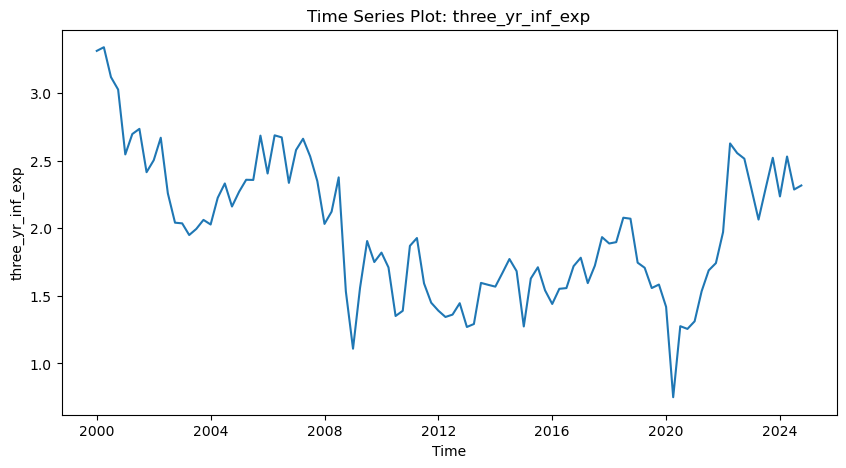

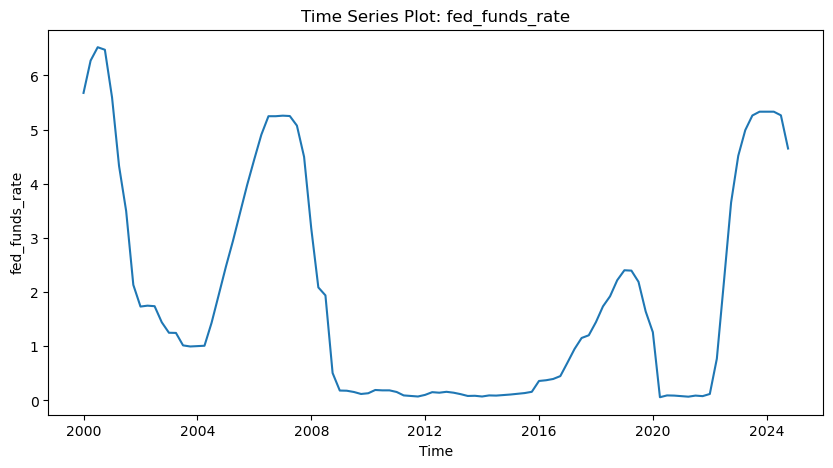

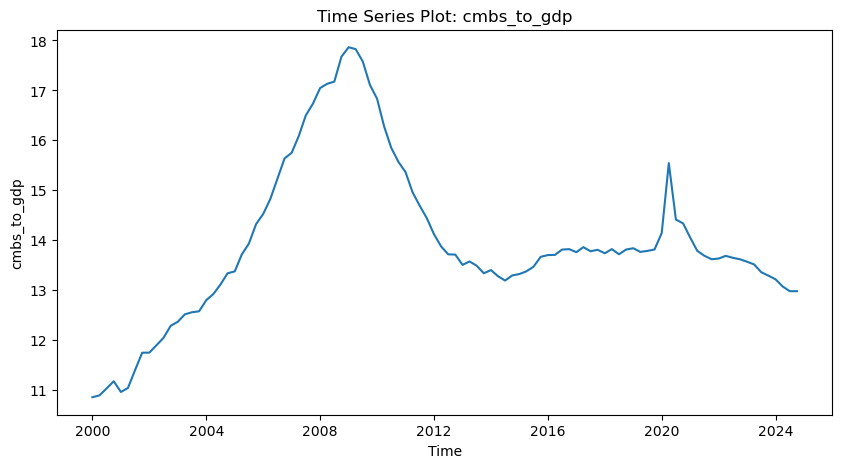

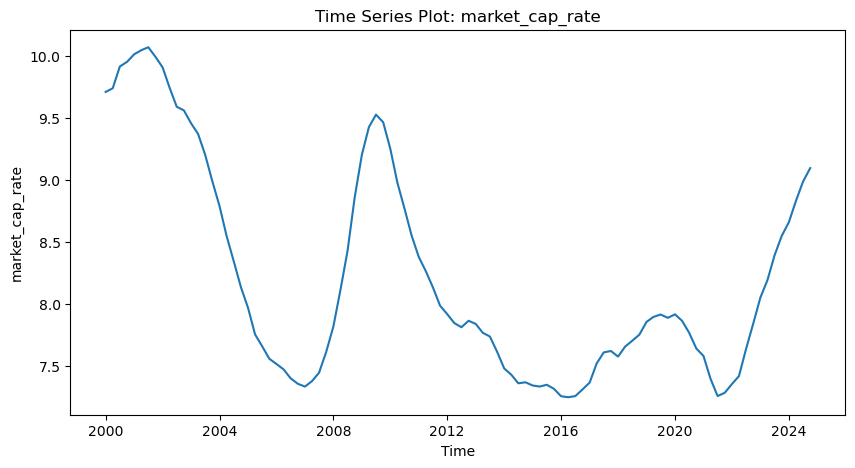


--- CORRELATION HEATMAP ---


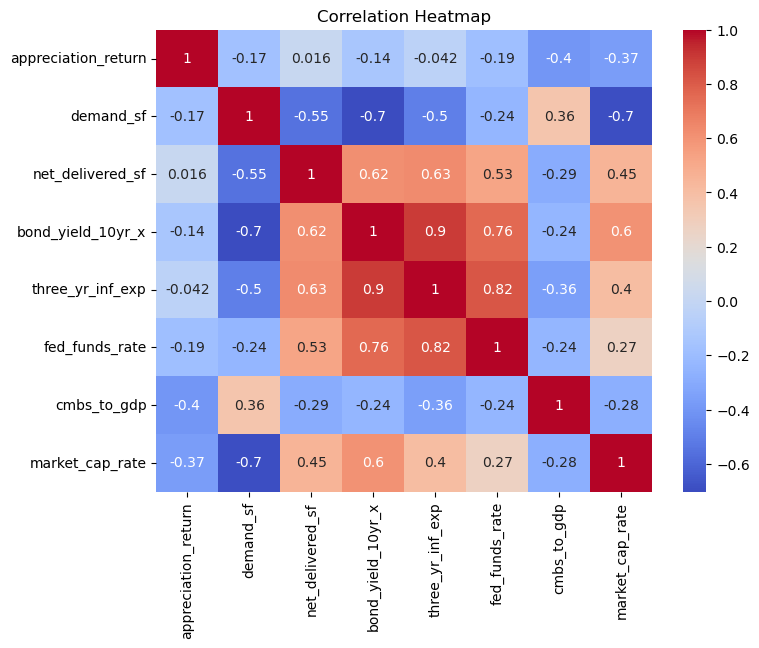


--- SEASONAL DECOMPOSITION ---


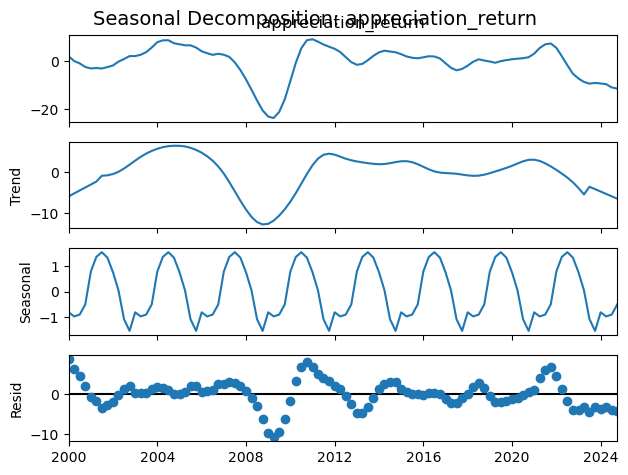

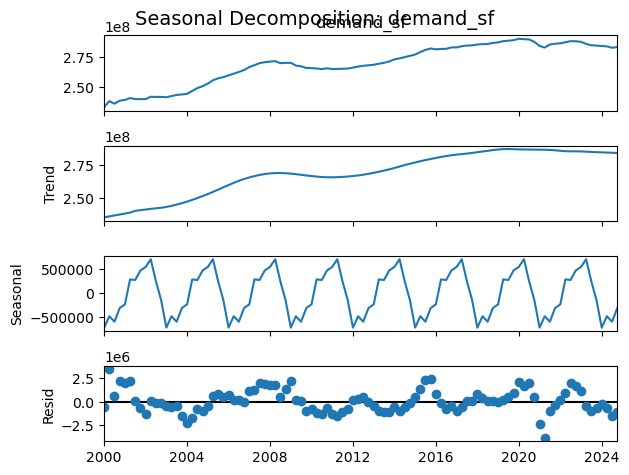

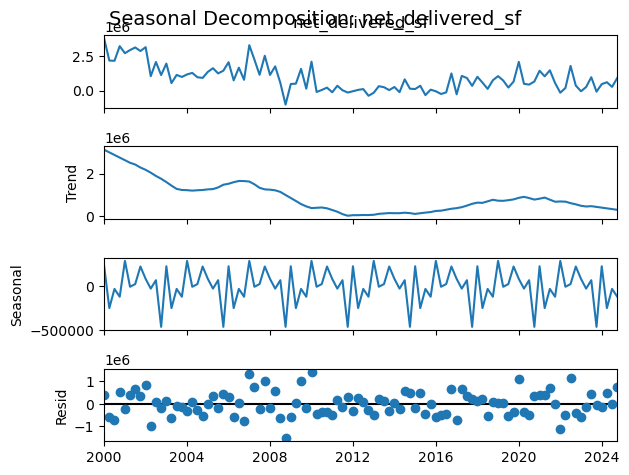

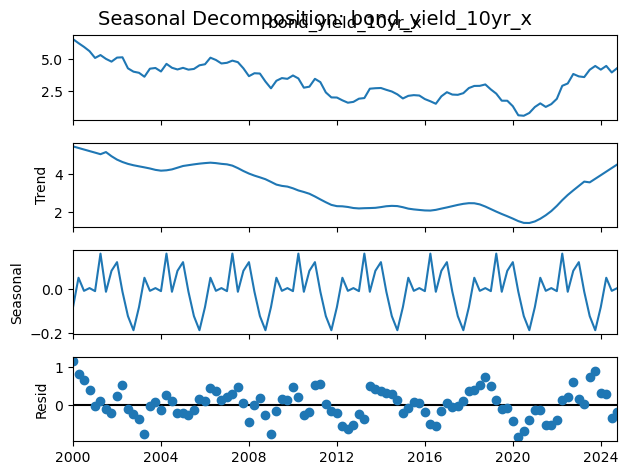

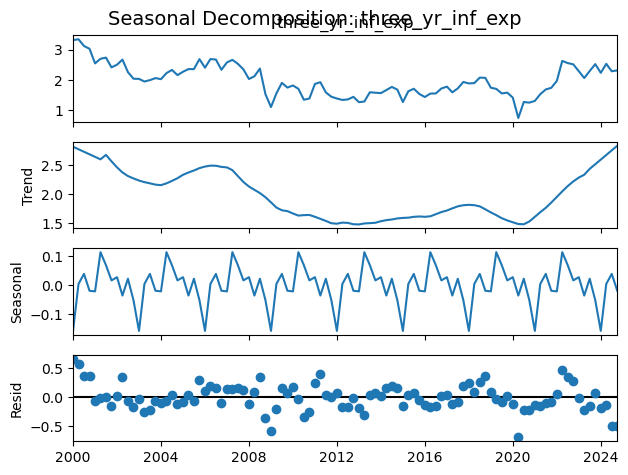

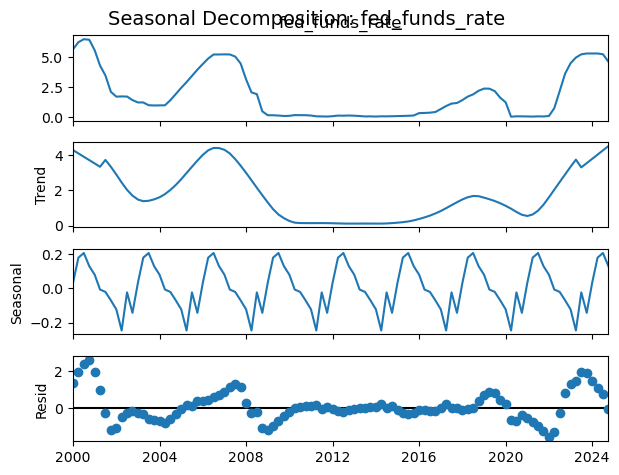

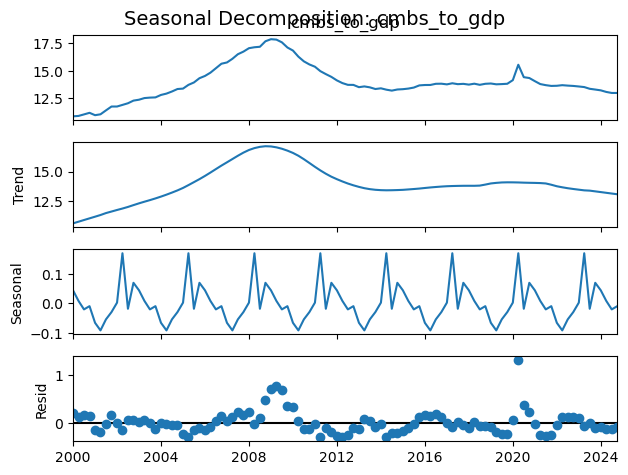

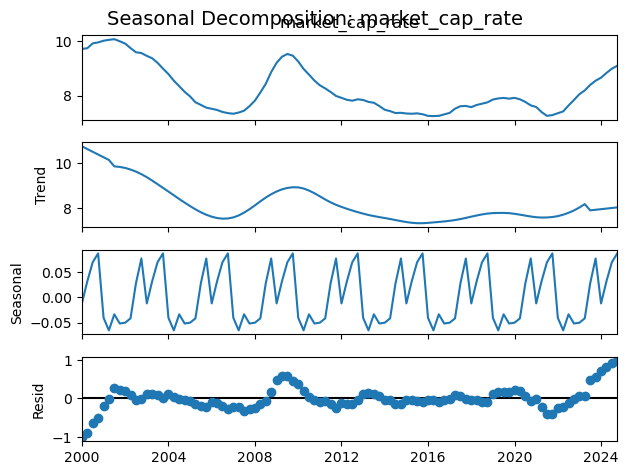


--- STATIONARITY CHECK (ADF TEST) ---
appreciation_return: ADF Statistic = -2.6534597450864226, p-value = 0.082443753772864
 - The series is NOT stationary.
demand_sf: ADF Statistic = -1.8886988814298455, p-value = 0.3373960469794508
 - The series is NOT stationary.
net_delivered_sf: ADF Statistic = -2.573779377498081, p-value = 0.09853853032168641
 - The series is NOT stationary.
bond_yield_10yr_x: ADF Statistic = -2.3608322961537778, p-value = 0.1530976369337716
 - The series is NOT stationary.
three_yr_inf_exp: ADF Statistic = -2.6931582496426607, p-value = 0.07522969191104313
 - The series is NOT stationary.
fed_funds_rate: ADF Statistic = -4.129792609756922, p-value = 0.0008643453554329658
 - The series is stationary.
cmbs_to_gdp: ADF Statistic = -2.178529909354208, p-value = 0.21412992930074526
 - The series is NOT stationary.
market_cap_rate: ADF Statistic = -2.96110356399515, p-value = 0.038689979217623564
 - The series is stationary.

--- KEY INSIGHTS ---
1. Variables with hi

In [31]:
# Automated EDA for Multivariate Time-Series

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

def run_eda(df, period_col='period'):
    # Ensure period column is datetime if present in the dataframe, otherwise assume it's already the index
    if period_col in df.columns:
        df[period_col] = pd.to_datetime(df[period_col])
        df.set_index(period_col, inplace=True)
    else:
        # Check if the index is already a datetime index
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
    
    print("\n--- BASIC INFORMATION ---")
    print(df.info())
    
    print("\n--- MISSING VALUES ---")
    print(df.isnull().sum())
    
    print("\n--- STATISTICAL SUMMARY ---")
    print(df.describe())
    
    print("\n--- TIME-SERIES PLOTS ---")
    for col in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df[col])
        plt.title(f'Time Series Plot: {col}')
        plt.xlabel('Time')
        plt.ylabel(col)
        plt.show()
        
    print("\n--- CORRELATION HEATMAP ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()
    
    print("\n--- SEASONAL DECOMPOSITION ---")
    for col in df.columns:
        result = seasonal_decompose(df[col], model='additive', period=12, extrapolate_trend='freq')
        result.plot()
        plt.suptitle(f'Seasonal Decomposition: {col}', fontsize=14)
        plt.show()
    
    print("\n--- STATIONARITY CHECK (ADF TEST) ---")
    for col in df.columns:
        result = adfuller(df[col].dropna())
        print(f'{col}: ADF Statistic = {result[0]}, p-value = {result[1]}')
        if result[1] <= 0.05:
            print(" - The series is stationary.")
        else:
            print(" - The series is NOT stationary.")
    
    print("\n--- KEY INSIGHTS ---")
    print("1. Variables with high correlations may indicate shared patterns.")
    print("2. Non-stationary variables may need differencing for modeling.")
    print("3. Seasonal decomposition highlights repetitive patterns and trends.")
    print("4. Missing values should be imputed or removed as appropriate.")
    
# Example usage:
run_eda(df, period_col='period')


In [33]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, target_col='market_cap_rate'):
    # Drop rows with missing values in the target column
    df = df.dropna(subset=[target_col])
    
    # Define the feature set (exclude the target variable)
    X = df.drop(columns=[target_col])
    
    # One-hot encode categorical variables (if any)
    X = pd.get_dummies(X, drop_first=True)
    
    # Add a constant for intercept
    X = sm.add_constant(X)
    
    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data['Variable'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    return vif_data

# Assuming df is provided, let's calculate VIF
vif_data = calculate_vif(df, target_col='market_cap_rate')
vif_data

,Variable,VIF
0,const,1701.491801
1,appreciation_return,1.537787
2,demand_sf,6.237873
3,net_delivered_sf,2.074957
4,bond_yield_10yr_x,19.485752
5,three_yr_inf_exp,10.309108
6,fed_funds_rate,4.856402
7,cmbs_to_gdp,1.787018


In [35]:
#remove the variables with high VIF
high_vif_cols = vif_data[vif_data['VIF'] > 5]['Variable'].tolist()
# Filter out columns that are not present in df
cols_to_drop = [col for col in high_vif_cols if col in df.columns]
df = df.drop(columns=cols_to_drop)
print("Removed columns with high VIF:", cols_to_drop)

Removed columns with high VIF: ['demand_sf', 'bond_yield_10yr_x', 'three_yr_inf_exp']



--- REGRESSION SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:        market_cap_rate   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     19.88
Date:                Fri, 21 Feb 2025   Prob (F-statistic):           3.43e-11
Time:                        19:29:34   Log-Likelihood:                -73.153
No. Observations:                  80   AIC:                             156.3
Df Residuals:                      75   BIC:                             168.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const 

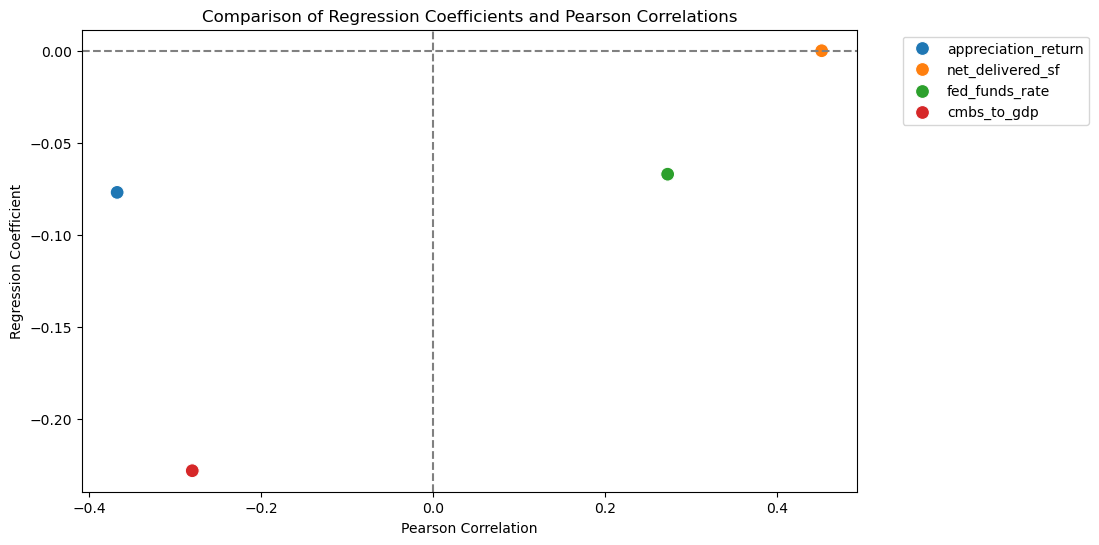

,Variable,Coefficient,P-Value,Pearson_Correlation
0,Intercept,1.111396e+01,5.494425e-23,NaN
1,appreciation_return,-7.697474e-02,3.410325e-09,-0.367267
2,net_delivered_sf,4.164151e-07,9.231313e-06,0.451587
3,fed_funds_rate,-6.709244e-02,1.113981e-01,0.272574
4,cmbs_to_gdp,-2.282172e-01,6.359869e-05,-0.279952


In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from scipy.stats import pearsonr

def regression_analysis(df, target_col='market_cap_rate'):
    # Drop rows with missing target variable
    df = df.dropna(subset=[target_col])
    
    # Separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # One-hot encode categorical variables (if any)
    X = pd.get_dummies(X, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Add constant for intercept in statsmodels
    X_train_sm = sm.add_constant(X_train)
    X_test_sm = sm.add_constant(X_test)

    # Fit regression using statsmodels
    model = sm.OLS(y_train, X_train_sm).fit()

    print("\n--- REGRESSION SUMMARY ---")
    print(model.summary())

    # Predict on test set
    y_pred = model.predict(X_test_sm)

    # Model evaluation
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n--- MODEL EVALUATION ---")
    print(f'Mean Squared Error (MSE): {mse:.4f}')
    print(f'Mean Absolute Error (MAE): {mae:.4f}')
    print(f'R-squared: {r2:.4f}')

    # Coefficients
    coef_df = pd.DataFrame({
        'Variable': ['Intercept'] + list(X.columns),
        'Coefficient': model.params.values,
        'P-Value': model.pvalues.values
    })

    # Calculate Pearson correlation coefficients
    print("\n--- PEARSON CORRELATION COEFFICIENTS ---")
    pearson_coeffs = []
    for col in X.columns:
        corr, _ = pearsonr(X[col], y)
        pearson_coeffs.append(corr)
    coef_df['Pearson_Correlation'] = [np.nan] + pearson_coeffs  # Intercept has no Pearson correlation

    # Display comparison
    print("\n--- COMPARISON: Regression Coefficients vs. Pearson Correlations ---")
    print(coef_df)

    # Visualize comparison
    coef_df_plot = coef_df.dropna()  # Remove intercept for plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=coef_df_plot, x='Pearson_Correlation', y='Coefficient', hue='Variable', s=100)
    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='gray', linestyle='--')
    plt.title('Comparison of Regression Coefficients and Pearson Correlations')
    plt.xlabel('Pearson Correlation')
    plt.ylabel('Regression Coefficient')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    return coef_df


# Example usage:
regression_analysis(df, target_col='market_cap_rate')


In [27]:
#print the missing values
print(df.isnull().sum())

appreciation_return     0
available_df_direct    21
demand_sf               0
net_delivered_sf        0
bond_yield_10yr_x       0
three_yr_inf_exp        0
fed_funds_rate          0
cmbs_to_gdp             1
market_cap_rate         0
dtype: int64


In [28]:
#drop available_df_direct
df = df.drop(columns=['available_df_direct'])

In [29]:
#forward fill the missing vlaue for cmbs_to_gdp
df['cmbs_to_gdp'] = df['cmbs_to_gdp'].fillna(method='ffill')

/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_14445/27647503.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['cmbs_to_gdp'] = df['cmbs_to_gdp'].fillna(method='ffill')


In [37]:
def predict_cap_rate(base_values, changes, coefficients, intercept=11.11396):
    """
    base_values: dict of baseline values for each predictor
    changes: dict of percentage changes for each predictor
    coefficients: dict of regression coefficients
    intercept: model intercept
    
    Returns the predicted cap rate after applying the changes.
    """
    predicted_cap_rate = intercept
    for var, coef in coefficients.items():
        change_amount = base_values[var] * (changes.get(var, 0) / 100)  # Convert % to decimal
        predicted_cap_rate += coef * change_amount
    return predicted_cap_rate

# Example Usage
base_values = {
    'appreciation_return': 0.05,   # Example baseline: 5%
    'net_delivered_sf': 1_000_000, # Example: 1 million sq ft
    'fed_funds_rate': 0.03,        # Example: 3%
    'cmbs_to_gdp': 0.02            # Example: 2%
}

changes = {
    'appreciation_return': 10,  # +10%
    'net_delivered_sf': 5,      # +5%
    'fed_funds_rate': 0.25,     # +0.25%
    'cmbs_to_gdp': -5           # -5%
}

coefficients = {
    'appreciation_return': -0.07697,
    'net_delivered_sf': 4.16e-07,
    'fed_funds_rate': -0.06709,
    'cmbs_to_gdp': -0.2282
}

predicted_rate = predict_cap_rate(base_values, changes, coefficients)
print(f"Predicted Market Cap Rate: {predicted_rate:.4f}%")


Predicted Market Cap Rate: 11.1346%
